<a href="https://colab.research.google.com/github/muhxz3/Student-Performance-Prediction/blob/main/Student_Habits_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [154]:
data = pd.read_csv("Day18_19_student_habits_performance.csv")
data

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [155]:
# EDA

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [156]:
data.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [157]:
data.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [158]:
# finding missing values

data.isna().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [159]:
data.parental_education_level.value_counts()

,count
parental_education_level,
High School,392
Bachelor,350
Master,167


In [160]:
# The parent's education is really important in how a student behaves. So it will be good to drop the null values instead of filling with any aggregate functions.

data = data.dropna(subset=["parental_education_level"])

In [161]:
data.shape

(909, 16)

In [162]:
data.duplicated().sum()

np.int64(0)

In [163]:
data

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


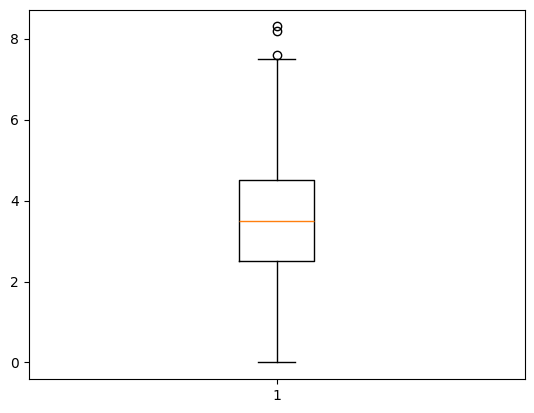

In [164]:
# identifying and removing outliers
plt.boxplot(data["study_hours_per_day"])
plt.show()

In [165]:
q1 = data["study_hours_per_day"].quantile(0.25)
q3 = data["study_hours_per_day"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

data["study_hours_per_day"] = data["study_hours_per_day"].clip(lower=lower_bound,upper=upper_bound)

/tmp/ipykernel_2792/2954031185.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["study_hours_per_day"] = data["study_hours_per_day"].clip(lower=lower_bound,upper=upper_bound)


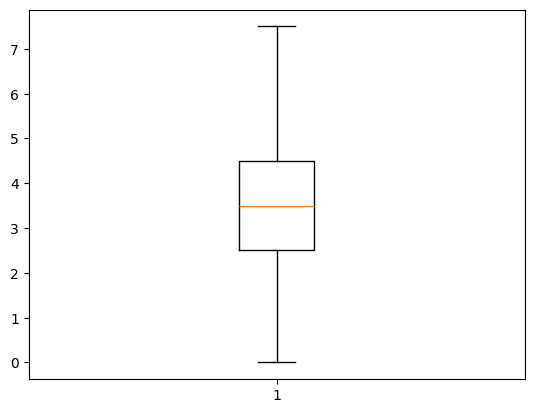

In [166]:
plt.boxplot(data["study_hours_per_day"])
plt.show()

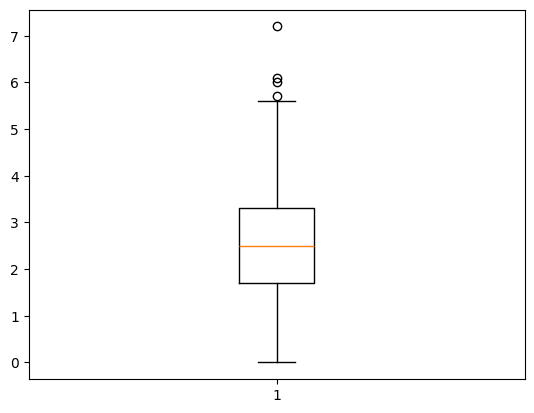

In [167]:
plt.boxplot(data["social_media_hours"])
plt.show()

In [168]:
q1 = data["social_media_hours"].quantile(0.25)
q3 = data["social_media_hours"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

data["social_media_hours"] = data["social_media_hours"].clip(lower=lower_bound,upper=upper_bound)

/tmp/ipykernel_2792/155899675.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["social_media_hours"] = data["social_media_hours"].clip(lower=lower_bound,upper=upper_bound)


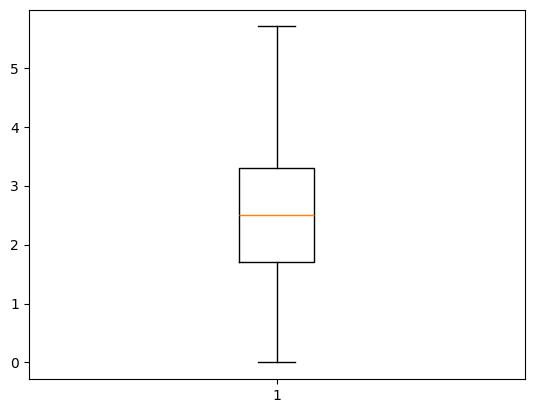

In [169]:
plt.boxplot(data["social_media_hours"])
plt.show()

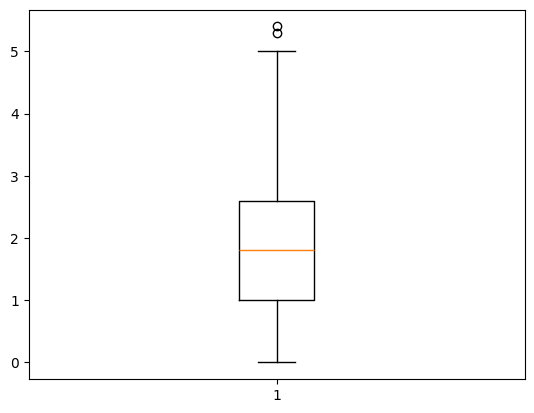

In [170]:
plt.boxplot(data["netflix_hours"])
plt.show()

In [171]:
q1 = data["netflix_hours"].quantile(0.25)
q3 = data["netflix_hours"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

data["netflix_hours"] = data["netflix_hours"].clip(lower=lower_bound,upper=upper_bound)

/tmp/ipykernel_2792/1882895440.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["netflix_hours"] = data["netflix_hours"].clip(lower=lower_bound,upper=upper_bound)


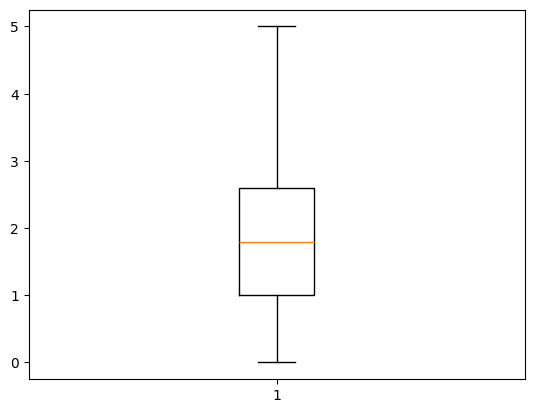

In [172]:
plt.boxplot(data["netflix_hours"])
plt.show()

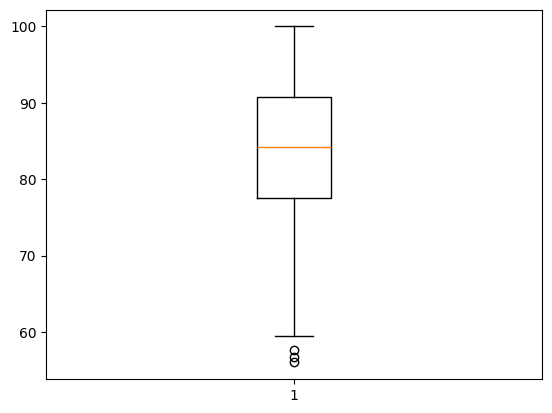

In [173]:
plt.boxplot(data["attendance_percentage"])
plt.show()

In [174]:
q1 = data["attendance_percentage"].quantile(0.25)
q3 = data["attendance_percentage"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

data["attendance_percentage"] = data["attendance_percentage"].clip(lower=lower_bound,upper=upper_bound)

/tmp/ipykernel_2792/1984065132.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["attendance_percentage"] = data["attendance_percentage"].clip(lower=lower_bound,upper=upper_bound)


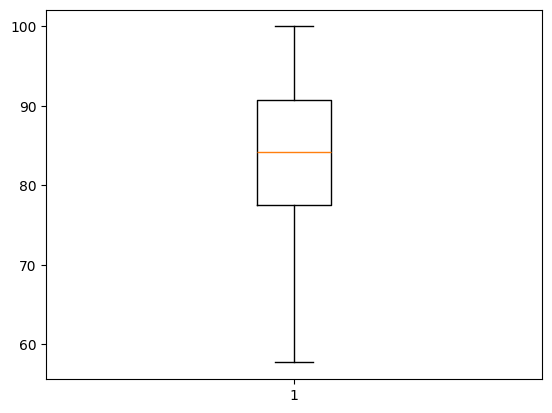

In [175]:
plt.boxplot(data["attendance_percentage"])
plt.show()

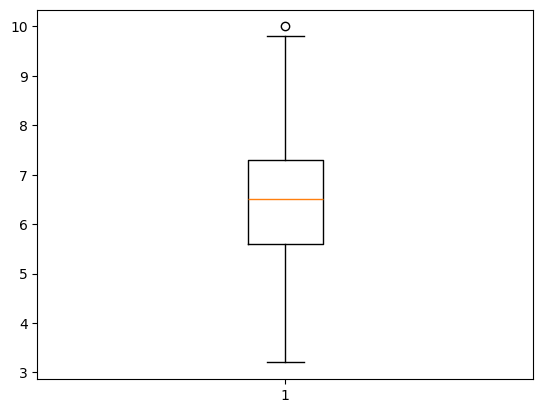

In [176]:
plt.boxplot(data["sleep_hours"])
plt.show()

In [177]:
q1 = data["sleep_hours"].quantile(0.25)
q3 = data["sleep_hours"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

data["sleep_hours"] = data["sleep_hours"].clip(lower=lower_bound,upper=upper_bound)

/tmp/ipykernel_2792/166148486.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["sleep_hours"] = data["sleep_hours"].clip(lower=lower_bound,upper=upper_bound)


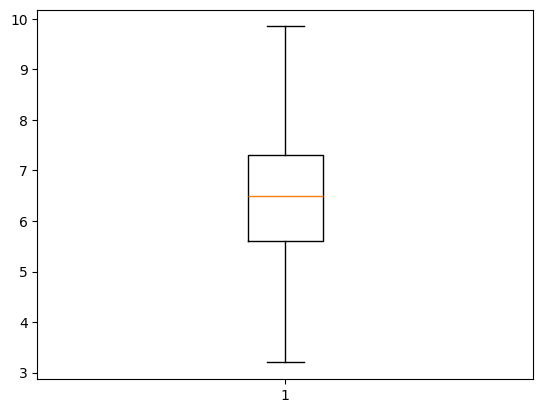

In [178]:
plt.boxplot(data["sleep_hours"])
plt.show()

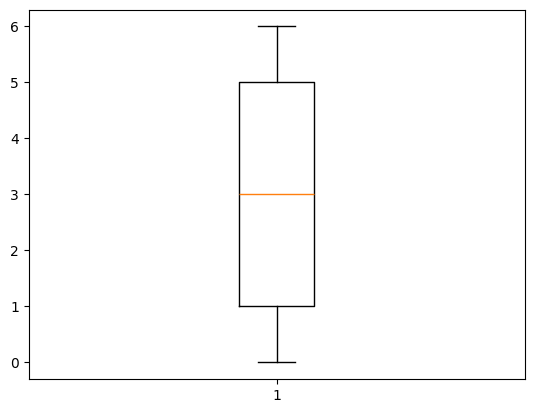

In [179]:
plt.boxplot(data["exercise_frequency"])
plt.show()

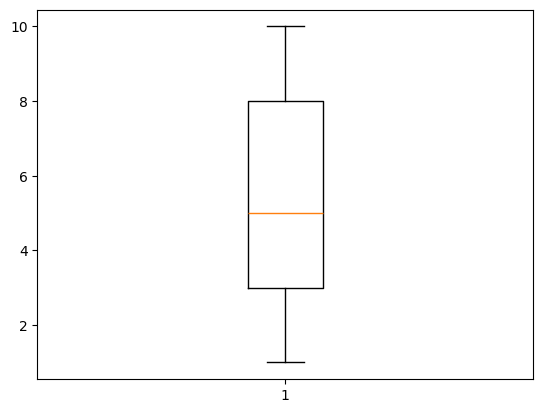

In [180]:
plt.boxplot(data["mental_health_rating"])
plt.show()

In [181]:
data.shape

(909, 16)

#### Features that can be used to create a model predicting the exam score:
- study_hours_per_day: How many hours the student study per day?
- social_media_hours: How many hours the student spent on social media?
- netflix_hours: someway similar to social_media_hours
- attendance_percentage: How much attendance the student have?
- sleep_hours: How much hours the student sleep?
- part_time_job: The part time job may affect the student's score
- exercise_frequency
- mental_health_rating
- parental_education_level

In [182]:
subs = data[["study_hours_per_day","social_media_hours","netflix_hours","attendance_percentage","sleep_hours","exercise_frequency","mental_health_rating"]]
subs

,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating
0,0.0,1.2,1.1,85.0,8.0,6,8
1,6.9,2.8,2.3,97.3,4.6,6,8
2,1.4,3.1,1.3,94.8,8.0,1,1
3,1.0,3.9,1.0,71.0,9.2,4,1
4,5.0,4.4,0.5,90.9,4.9,3,1
...,...,...,...,...,...,...,...
995,2.6,0.5,1.6,77.0,7.5,2,6
996,2.9,1.0,2.4,86.0,6.8,1,6
997,3.0,2.6,1.3,61.9,6.5,5,9
998,5.4,4.1,1.1,100.0,7.6,0,1


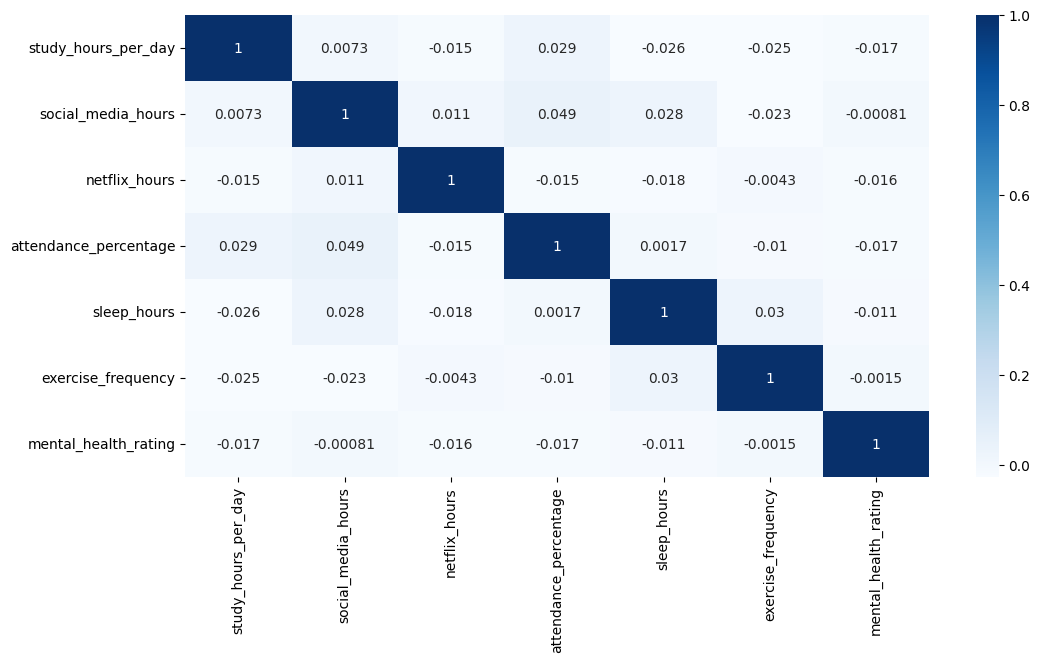

In [183]:
plt.subplots(figsize=(12,6))
sns.heatmap(subs.corr(),annot=True,cmap="Blues")
plt.show()

In [186]:
from sklearn.preprocessing import LabelEncoder
le_job = LabelEncoder()
le_education = LabelEncoder()

In [188]:
data["part_time_job"] = le_job.fit_transform(data["part_time_job"])
data["parental_education_level"] = le_education.fit_transform(data["parental_education_level"])

/tmp/ipykernel_2792/1802387089.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["part_time_job"] = le_job.fit_transform(data["part_time_job"])
/tmp/ipykernel_2792/1802387089.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["parental_education_level"] = le_education.fit_transform(data["parental_education_level"])


In [189]:
data

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,0,85.0,8.0,Fair,6,2,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,0,97.3,4.6,Good,6,1,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,0,94.8,8.0,Poor,1,1,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,0,71.0,9.2,Poor,4,2,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,0,90.9,4.9,Fair,3,2,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,0,77.0,7.5,Fair,2,1,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,1,86.0,6.8,Poor,1,1,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,0,61.9,6.5,Good,5,0,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,1,100.0,7.6,Fair,0,0,Average,1,No,69.7


In [190]:
X = data[["study_hours_per_day","social_media_hours","netflix_hours","attendance_percentage","sleep_hours","exercise_frequency","mental_health_rating","part_time_job","parental_education_level"]]
y = data["exam_score"]

y = np.array(y).reshape(-1,1)

In [191]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [193]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [194]:
model.fit(X_train,y_train)

LinearRegression()

In [195]:
model.predict(X_test)

array([[ 61.86261401],
       [ 51.16891277],
       [ 70.68190657],
       [ 70.72148472],
       [ 87.65398406],
       [ 64.14855031],
       [ 78.17186753],
       [ 93.84120722],
       [ 66.60677478],
       [ 67.62915048],
       [ 56.44364368],
       [ 76.78644625],
       [ 57.49089971],
       [ 49.5164538 ],
       [ 77.4040798 ],
       [ 76.64334111],
       [ 48.77428668],
       [ 90.34609178],
       [ 84.86780698],
       [ 64.89490505],
       [ 74.46833571],
       [ 98.17441001],
       [ 54.54248746],
       [ 68.08113725],
       [ 82.3030237 ],
       [ 64.05942243],
       [105.04172891],
       [ 77.36159768],
       [ 60.57857943],
       [103.39726118],
       [ 60.39991375],
       [ 81.86308808],
       [ 54.06045202],
       [ 64.15255763],
       [ 61.88472647],
       [ 64.64447775],
       [ 98.56391731],
       [ 56.05922164],
       [ 60.24212183],
       [ 74.42180392],
       [ 60.46460738],
       [ 84.66823275],
       [ 69.04047423],
       [ 69

In [197]:
model.score(X_test,y_test)

0.8895583767710705

In [201]:
# Checking for underfitting or overfitting

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.9039447057194845
Test Accuracy: 0.8895583767710705


In [204]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = model.score(X_test, y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 29.97750574575011
R-squared: 0.8895583767710705
Mean Absolute Error: 4.22722859257879
Root Mean Squared Error: 5.475171754908709


In [205]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()

In [206]:
data["score_class"] = (data["exam_score"] >= 50).astype(int)

/tmp/ipykernel_2792/2897124242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["score_class"] = (data["exam_score"] >= 50).astype(int)


In [207]:
y = data["score_class"]
y = np.array(y).reshape(-1,1)

In [209]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [210]:
log_model.fit(X_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [211]:
log_model.predict(X_test)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1])

In [212]:
log_model.score(X_test,y_test)

0.9725274725274725

In [213]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
y_pred = log_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.9725274725274725
Precision: 0.9761904761904762
Recall: 0.9939393939393939
F1 Score: 0.984984984984985
Confusion Matrix:
 [[ 13   4]
 [  1 164]]


In [214]:
# finding whether there is an underfitting or overfitting problem

train_accuracy = log_model.score(X_train, y_train)
test_accuracy = log_model.score(X_test, y_test)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.9491059147180193
Test Accuracy: 0.9725274725274725


# KEY INSIGHTS:
- Both Models have the best accuracy score.
- Both Models show the best results.
- The confusion matrix for Logistic Regression Model is as follows:<br>
[[13  4]<br>
[1  164]]
- The Logistic Regression model achieved an accuracy of 97.25%, correctly classifying 177 of 182 students. Its precision of 97.62% indicates that most students predicted to be above 50 were actually above 50. The recall of 99.39% shows that the model successfully identified almost all students who actually scored above 50. The F1 score of 98.50% indicates an excellent balance between precision and recall.
- There is a slight overfitting problem in Linear Regression Model
- There were 9 input features for predicting the exam score
- The Linear Regression Model has a score of 88% whereas the Logistic Regression Model has a score of 97%.

